# Multimodal Support-Need Index (SNI)

An interpretable, training-free index that flags moments where the operator likely needs support: hands pause while gaze disperses or moves to the instruction sheet ("I'm stuck, let me check").

SNI fuses three sub-signals from gaze and hands:

1. **gaze entropy** - dispersed gaze => visual search
2. **hand stall** - low joint motion => paused execution
3. **instruction-AOI dwell** - gaze on the instruction sheet => consulting guidance

```
SNI_t = sigmoid((z_gaze_entropy_t + z_hand_stall_t + z_instruction_AOI_t) / 3)
```

Each signal is z-scored per recording, fused with equal weights, and a per-recording episode threshold (mean + 1 std) marks support-need episodes. There is no ground-truth support label, so we evaluate with ROC-AUC against a weak instruction-consulting proxy from `AR_labels`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make src/ importable.
sys.path.append(os.path.abspath(os.path.join("..", "src")))

from constants import ALL_RECORDINGS, WINDOW_SIZE, GRID_SIZE
from data_utils import recording_dir, load_recording, split_of
from gaze_features import compute_gaze_entropy, compute_instruction_aoi_dwell
from hand_features import compute_hand_stall
from sni_utils import compute_sni, detect_support_episodes, extract_episode_table
from eval_utils import build_instruction_proxy, compute_auc, compute_ablation_auc
import plot_utils

OUT_DIR = os.path.abspath(os.path.join("..", "outputs"))
PLOT_DIR = os.path.join(OUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
ALL_RECORDINGS

['22_assy_0_1', '22_assy_2_3', '25_assy_0_1', '25_assy_2_1', '27_assy_0_1']

## 1. Compute SNI per recording

For each recording: load gaze + hands, compute the three sub-signals over a 30-frame window, z-score and fuse them, detect episodes, and attach the weak proxy.

In [2]:
per_frame_rows = []

for rec in ALL_RECORDINGS:
    rdir = recording_dir(rec)
    frames, gaze, hands = load_recording(rdir)

    gaze_entropy = compute_gaze_entropy(gaze, window=WINDOW_SIZE, grid_size=GRID_SIZE)
    hand_stall = compute_hand_stall(hands, window=WINDOW_SIZE)
    aoi_dwell = compute_instruction_aoi_dwell(gaze, window=WINDOW_SIZE)

    sni, z_gaze, z_stall, z_dwell = compute_sni(gaze_entropy, hand_stall, aoi_dwell)
    episode_mask, threshold = detect_support_episodes(sni)
    proxy = build_instruction_proxy(rdir, frames)

    # Save one episode table per recording.
    episodes = extract_episode_table(frames, sni, episode_mask, rec)
    episodes.to_csv(os.path.join(OUT_DIR, f"episodes_{rec}.csv"), index=False)

    for i, f in enumerate(frames):
        per_frame_rows.append(dict(
            recording=rec,
            frame=f,
            frame_index=i,
            gaze_entropy=gaze_entropy[i],
            hand_stall=hand_stall[i],
            instruction_aoi_dwell=aoi_dwell[i],
            z_gaze_entropy=z_gaze[i],
            z_hand_stall=z_stall[i],
            z_instruction_aoi_dwell=z_dwell[i],
            sni=sni[i],
            episode_threshold=threshold,
            support_episode=int(episode_mask[i]),
            instruction_proxy=int(proxy[i]),
            split=split_of(rec),
        ))
    print(f"{rec}: frames={len(frames)} episodes={len(episodes)} "
          f"AUC={compute_auc(proxy, sni):.3f}")

per_frame = pd.DataFrame(per_frame_rows)
per_frame.to_csv(os.path.join(OUT_DIR, "sni_per_frame.csv"), index=False)
per_frame.head()

22_assy_0_1: frames=2738 episodes=29 AUC=0.648


22_assy_2_3: frames=3065 episodes=28 AUC=0.297


25_assy_0_1: frames=1798 episodes=24 AUC=0.696


25_assy_2_1: frames=1340 episodes=15 AUC=0.791


27_assy_0_1: frames=2781 episodes=34 AUC=0.804


,recording,frame,frame_index,gaze_entropy,hand_stall,instruction_aoi_dwell,z_gaze_entropy,z_hand_stall,z_instruction_aoi_dwell,sni,episode_threshold,support_episode,instruction_proxy,split
0,22_assy_0_1,000000.jpg,0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.500000,0.625283,0,1,train
1,22_assy_0_1,000001.jpg,1,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.500000,0.625283,0,1,train
2,22_assy_0_1,000002.jpg,2,-0.000000,NaN,0.0,-3.132405,0.000000,-0.866197,0.208685,0.625283,0,1,train
3,22_assy_0_1,000003.jpg,3,0.811278,-38.876486,0.0,-2.002057,0.601378,-0.866197,0.319597,0.625283,0,1,train
4,22_assy_0_1,000004.jpg,4,0.970951,-40.621347,0.0,-1.779587,0.571022,-0.866197,0.333680,0.625283,0,1,train


## 2. Per-recording and pooled AUC

ROC-AUC of the fused SNI against the weak instruction-consulting proxy.

In [3]:
rows = []
for rec in ALL_RECORDINGS:
    df = per_frame[per_frame["recording"] == rec]
    proxy = df["instruction_proxy"].values.astype(bool)
    sni = df["sni"].values
    rows.append(dict(
        recording=rec,
        auc=compute_auc(proxy, sni),
        num_frames=len(df),
        num_proxy_positive=int(proxy.sum()),
        num_episode_frames=int(df["support_episode"].sum()),
        mean_sni_proxy_positive=float(np.nanmean(sni[proxy])) if proxy.any() else np.nan,
        mean_sni_proxy_negative=float(np.nanmean(sni[~proxy])) if (~proxy).any() else np.nan,
    ))

# Pooled row across all frames.
proxy_all = per_frame["instruction_proxy"].values.astype(bool)
sni_all = per_frame["sni"].values
rows.append(dict(
    recording="pooled",
    auc=compute_auc(proxy_all, sni_all),
    num_frames=len(per_frame),
    num_proxy_positive=int(proxy_all.sum()),
    num_episode_frames=int(per_frame["support_episode"].sum()),
    mean_sni_proxy_positive=float(np.nanmean(sni_all[proxy_all])),
    mean_sni_proxy_negative=float(np.nanmean(sni_all[~proxy_all])),
))

recording_auc = pd.DataFrame(rows)
recording_auc.to_csv(os.path.join(OUT_DIR, "recording_auc.csv"), index=False)
recording_auc.round(3)

,recording,auc,num_frames,num_proxy_positive,num_episode_frames,mean_sni_proxy_positive,mean_sni_proxy_negative
0,22_assy_0_1,0.648,2738,437,483,0.553,0.491
1,22_assy_2_3,0.297,3065,46,560,0.395,0.502
2,25_assy_0_1,0.696,1798,405,278,0.567,0.481
3,25_assy_2_1,0.791,1340,222,296,0.596,0.482
4,27_assy_0_1,0.804,2781,705,536,0.603,0.468
5,pooled,0.716,11722,1815,2153,0.577,0.487


## 3. Ablation

Pooled AUC of each single z-scored signal versus the fused SNI. Against this proxy the AOI-dwell component dominates (it measures almost what the proxy measures); `hand_stall` is below chance because stalling does not specifically co-occur with instruction checking. Fusing keeps the index broader than the proxy alone - this is expected, not tuned away.

In [4]:
ablation = compute_ablation_auc(
    proxy_all,
    per_frame["z_gaze_entropy"].values,
    per_frame["z_hand_stall"].values,
    per_frame["z_instruction_aoi_dwell"].values,
    sni_all,
)

descriptions = {
    "Instruction-AOI dwell only": "gaze fraction inside the instruction AOI",
    "Fused SNI": "equal-weight sigmoid fusion of all three signals",
    "Gaze entropy only": "rolling spatial entropy of gaze",
    "Hand stall only": "negative rolling hand-joint motion",
}
ablation_auc = pd.DataFrame([
    dict(signal=s, pooled_auc=ablation[s], description=descriptions[s])
    for s in ["Instruction-AOI dwell only", "Fused SNI", "Gaze entropy only", "Hand stall only"]
])
ablation_auc.to_csv(os.path.join(OUT_DIR, "ablation_auc.csv"), index=False)
ablation_auc.round(3)

,signal,pooled_auc,description
0,Instruction-AOI dwell only,0.778,gaze fraction inside the instruction AOI
1,Fused SNI,0.716,equal-weight sigmoid fusion of all three signals
2,Gaze entropy only,0.608,rolling spatial entropy of gaze
3,Hand stall only,0.407,negative rolling hand-joint motion


## 4. Plots from the saved CSVs

Plots are drawn from the saved CSV files, not recomputed from raw data.

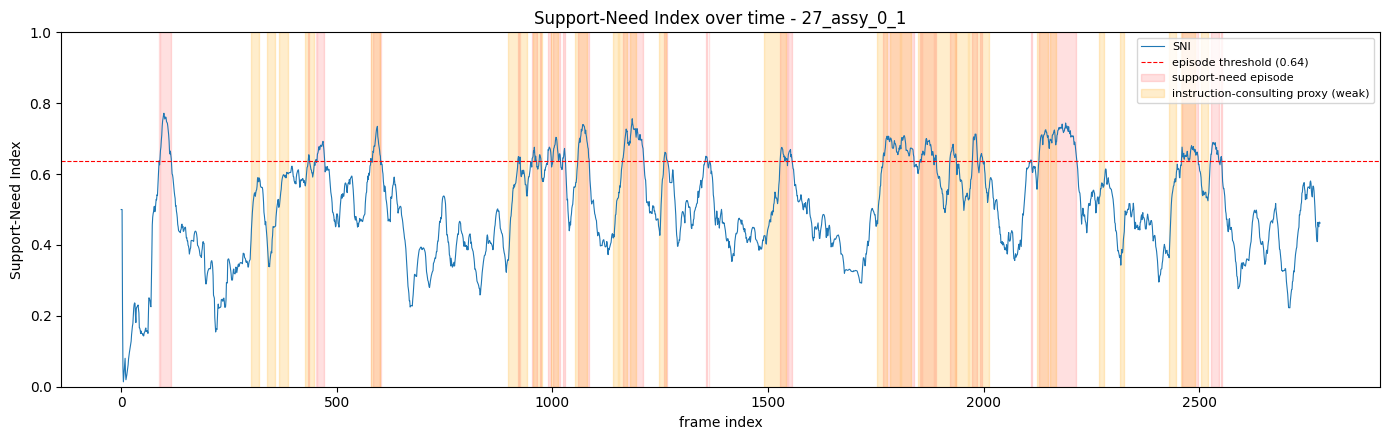

In [5]:
per_frame_csv = pd.read_csv(os.path.join(OUT_DIR, "sni_per_frame.csv"))
recording_auc_csv = pd.read_csv(os.path.join(OUT_DIR, "recording_auc.csv"))
ablation_auc_csv = pd.read_csv(os.path.join(OUT_DIR, "ablation_auc.csv"))

plot_utils.plot_sni_timeline(
    per_frame_csv, "27_assy_0_1",
    save_path=os.path.join(PLOT_DIR, "sni_timeline_27_assy_0_1.png"))
plt.show()

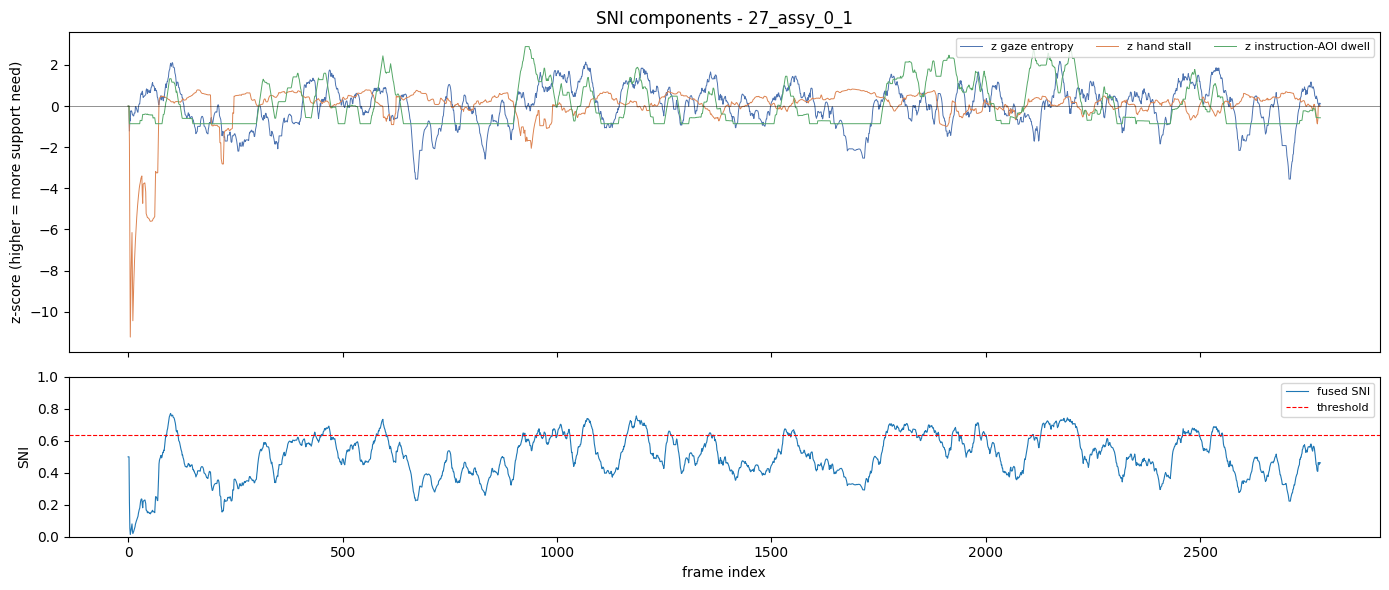

In [6]:
plot_utils.plot_signal_components(
    per_frame_csv, "27_assy_0_1",
    save_path=os.path.join(PLOT_DIR, "sni_signal_components.png"))
plt.show()

C:\Users\purus\Documents\Work\resume\PhD\Uppasala\Multimodal AI and XR for Human-Centric Manufacturing\3rd\AI_XR\task2\src\plot_utils.py:76: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df["recording"], rotation=40, ha="right", fontsize=8)


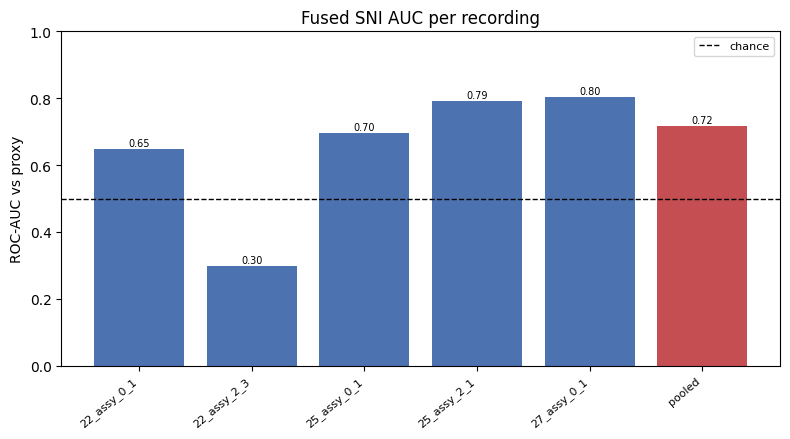

In [7]:
plot_utils.plot_recording_auc(
    recording_auc_csv,
    save_path=os.path.join(PLOT_DIR, "recording_auc_bar.png"))
plt.show()

C:\Users\purus\Documents\Work\resume\PhD\Uppasala\Multimodal AI and XR for Human-Centric Manufacturing\3rd\AI_XR\task2\src\plot_utils.py:97: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df["signal"], rotation=20, ha="right", fontsize=8)


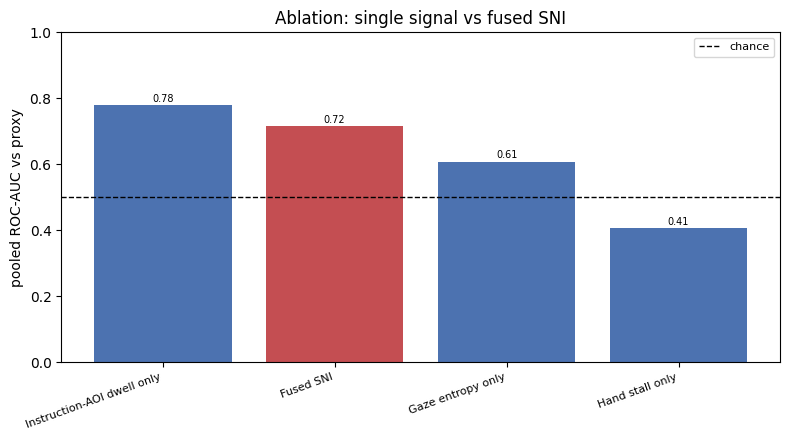

In [8]:
plot_utils.plot_ablation_auc(
    ablation_auc_csv,
    save_path=os.path.join(PLOT_DIR, "ablation_auc_bar.png"))
plt.show()

## 5. Summary

The fused SNI tracks the weak instruction-consulting proxy (pooled AUC ~0.72, test recording ~0.80) without any training. It deliberately captures more than instruction consulting (stall-based hesitation the proxy cannot see), so the proxy AUC is directional evidence, not a detector score. See `README.md` for the full method, limitations and practical relevance.